In [63]:
%loadlibs
import torch.nn.functional as F
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


We work with the following equation
$$\dot{x}(t) = x(t) (x(t)-1)$$

In [98]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

def plot_phase_line(f, xlim=(-4, 4), n_scan=2000, title=None, ax=None):
    xmin, xmax = xlim
    xs = np.linspace(xmin, xmax, n_scan)
    fs = f(xs)

    # Find equilibria via sign changes on the scan grid
    eqs = []
    for i in range(len(xs) - 1):
        if fs[i] == 0:
            eqs.append(xs[i])
        elif fs[i] * fs[i + 1] < 0:
            eqs.append(brentq(f, xs[i], xs[i + 1]))
    eqs = sorted(set(np.round(eqs, 8)))

    bounds = [xmin] + eqs + [xmax]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 2))

    ax.hlines(0, xmin, xmax, color='black')

    # Equilibria: filled = stable, open = unstable
    eps = 1e-4 * (xmax - xmin)
    for eq in eqs:
        stable = f(eq - eps) > 0 and f(eq + eps) < 0
        ax.plot(eq, 0, 'o', markersize=8,
                 markerfacecolor='red' if stable else 'white',
                 markeredgecolor='red')

    # Arrows: direction given by sign of f in each interval
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        if hi - lo < 1e-6:
            continue
        for x0 in np.linspace(lo, hi, 7)[1:-1]:
            d = np.sign(f(x0))
            if d != 0:
                ax.arrow(x0, 0, 0.1 * d, 0, head_width=0.03, head_length=0.08,
                          length_includes_head=True, color='green')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.1, 0.1)
    ax.set_yticks([])
    ax.set_xlabel(r"$x$")
    if title:
        ax.set_title(title)
    ax.grid(axis='x')
    return ax

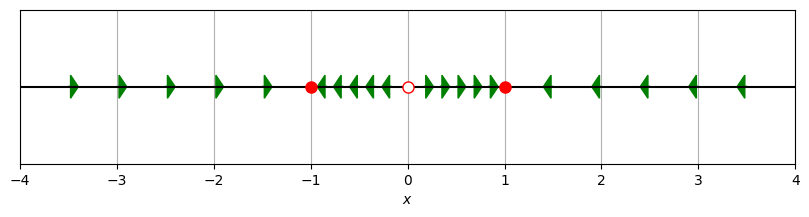

In [102]:
plot_phase_line(lambda x: -x * (x-1) * (x+1))
plt.show()

In [103]:
T_MAX = 1.

In [123]:
class Model(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.l1 = nn.Linear(2, hidden)
        self.l2 = nn.Linear(hidden, hidden)
        self.l3 = nn.Linear(hidden, 1)
        self.activation = nn.Tanh()
        
    def forward(self, t, x0):
        inp = torch.cat([t, x0], dim=1)
        h = self.activation(self.l1(inp))
        h = self.activation(self.l2(h))
        nn_out = self.l3(h)
        return nn_out * t + x0

def loss_fn(model, t, x0):
    t = t.clone().requires_grad_(True)
    x0 = x0.clone().requires_grad_(True)
    x = model(t, x0)
    dx_dt = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True, retain_graph=True)[0]
    residual = dx_dt - (-x * (x-1) * (x+1))
    physics_loss = torch.mean(residual ** 2)
    return physics_loss

n_epochs = 20000
n_points = 10000
model = Model(128)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)

for _ in (pbar := tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = torch.rand((n_points, 1)) * T_MAX
    x0 = (torch.rand((n_points, 1)) - 0.5) * 8
    loss = loss_fn(model, t, x0)
    pbar.set_description(f"Loss: {loss.item():.4e} - lr: {scheduler.get_last_lr()[-1]:.3e}")
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())

  0%|          | 0/20000 [00:00<?, ?it/s]

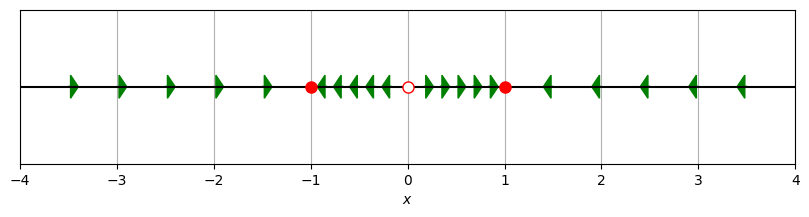

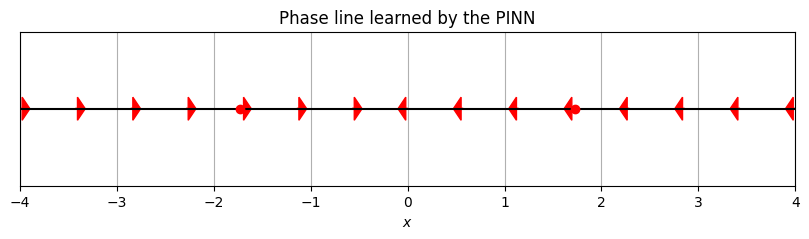

In [124]:
x = torch.linspace(-4, 4, 15).unsqueeze(-1)
t = torch.ones_like(x, requires_grad=True) * 1e-6

x_pred = model(t, x)

dxdt = torch.autograd.grad(
    outputs=x_pred,
    inputs=t,
    grad_outputs=torch.ones_like(x_pred),
)[0]

x_np = x.cpu().detach().numpy().flatten()
dxdt_np = dxdt.cpu().detach().numpy().flatten()

plot_phase_line(lambda x: -x*(x-1)*(x+1))
plt.show()

plt.figure(figsize=(10, 2))
plt.hlines(0, -4, 4, color="black")

for xi, fi in zip(x_np, dxdt_np):
    direction = np.sign(fi)
    if direction == 0:
        continue
    plt.arrow(xi, 0, 0.1 * direction, 0, head_width=0.03, head_length=0.08, length_includes_head=True, color="red")
xeq = np.sqrt(mu_value)
plt.plot([-xeq, xeq], [0, 0], "ro")

plt.xlim(-4, 4)
plt.ylim(-0.1, 0.1)
plt.yticks([])
plt.xlabel(r"$x$")
plt.title("Phase line learned by the PINN")
plt.grid(axis="x")

plt.show()

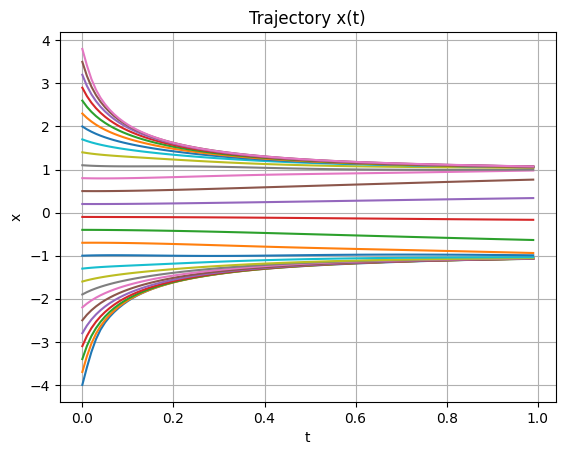

In [125]:
t = torch.arange(0, T_MAX, 0.01).unsqueeze(-1)
for i in np.arange(-4, 4, 0.3):
    x0 = torch.ones_like(t) * i
    plt.plot(t.cpu(), model(t, x0).cpu().detach())
    plt.xlabel("t")
    plt.ylabel("x")
    plt.grid()
    plt.title("Trajectory x(t)")

In [126]:
def loss_fn_2(model, t, x0):
    t = t.clone().requires_grad_(True)
    x0 = x0.clone().requires_grad_(True)

    x = model(t, x0)

    dx_dt = torch.autograd.grad(
        x, t, grad_outputs=torch.ones_like(x),
        create_graph=True, retain_graph=True
    )[0]

    f = -x * (x - 1) * (x + 1)
    residual = dx_dt - f
    physics_loss = torch.mean(residual ** 2)

    dx_dx0 = torch.autograd.grad(
        x, x0, grad_outputs=torch.ones_like(x),
        create_graph=True, retain_graph=True
    )[0]

    d_dxdt_dx0 = torch.autograd.grad(
        dx_dt, x0, grad_outputs=torch.ones_like(dx_dt),
        create_graph=True, retain_graph=True
    )[0]

    f_prime = -3 * x**2 + 1
    sensitivity_residual = d_dxdt_dx0 - f_prime * dx_dx0
    divergence_loss = torch.mean(sensitivity_residual ** 2)

    return physics_loss + divergence_loss

class Model(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.l1 = nn.Linear(2, hidden)
        self.l2 = nn.Linear(hidden, hidden)
        self.l3 = nn.Linear(hidden, 1)
        self.activation = nn.Tanh()
        
    def forward(self, t, x0):
        inp = torch.cat([t, x0], dim=1)
        h = self.activation(self.l1(inp))
        h = self.activation(self.l2(h))
        nn_out = self.l3(h)
        return nn_out * t + x0

n_epochs = 20000
n_points = 10000
model = Model(128)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)

for _ in (pbar := tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = torch.rand((n_points, 1)) * T_MAX
    x0 = (torch.rand((n_points, 1)) - 0.5) * 8
    loss = loss_fn_2(model, t, x0)
    pbar.set_description(f"Loss: {loss.item():.4e} - lr: {scheduler.get_last_lr()[-1]:.3e}")
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())

  0%|          | 0/20000 [00:00<?, ?it/s]

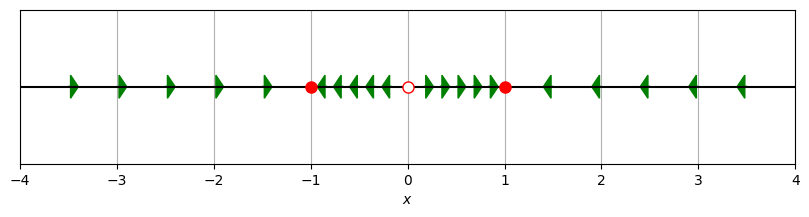

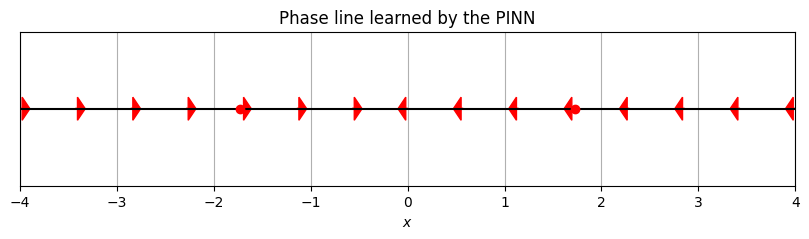

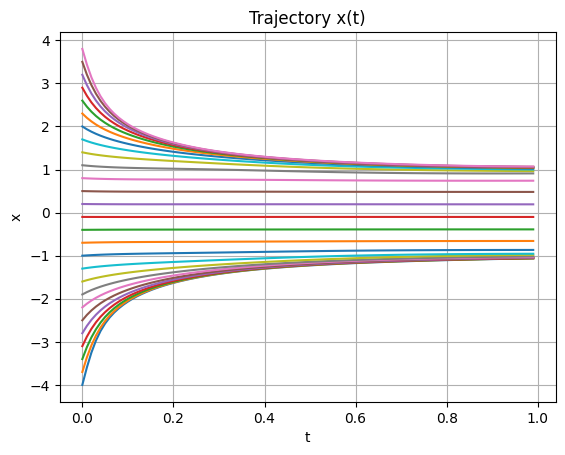

In [127]:
x = torch.linspace(-4, 4, 15).unsqueeze(-1)
t = torch.ones_like(x, requires_grad=True) * 1e-6

x_pred = model(t, x)

dxdt = torch.autograd.grad(
    outputs=x_pred,
    inputs=t,
    grad_outputs=torch.ones_like(x_pred),
)[0]

x_np = x.cpu().detach().numpy().flatten()
dxdt_np = dxdt.cpu().detach().numpy().flatten()

plot_phase_line(lambda x: -x*(x-1)*(x+1))
plt.show()

plt.figure(figsize=(10, 2))
plt.hlines(0, -4, 4, color="black")

for xi, fi in zip(x_np, dxdt_np):
    direction = np.sign(fi)
    if direction == 0:
        continue
    plt.arrow(xi, 0, 0.1 * direction, 0, head_width=0.03, head_length=0.08, length_includes_head=True, color="red")
xeq = np.sqrt(mu_value)
plt.plot([-xeq, xeq], [0, 0], "ro")

plt.xlim(-4, 4)
plt.ylim(-0.1, 0.1)
plt.yticks([])
plt.xlabel(r"$x$")
plt.title("Phase line learned by the PINN")
plt.grid(axis="x")

plt.show()

t = torch.arange(0, T_MAX, 0.01).unsqueeze(-1)
for i in np.arange(-4, 4, 0.3):
    x0 = torch.ones_like(t) * i
    plt.plot(t.cpu(), model(t, x0).cpu().detach())
    plt.xlabel("t")
    plt.ylabel("x")
    plt.grid()
    plt.title("Trajectory x(t)")